[*********************100%***********************]  1 of 1 completed


Loaded: 2261

=== LOG RETURNS (First 5 rows) ===
2017-01-04 | Close: 26.72 | LogReturn: -0.00112
2017-01-05 | Close: 26.85 | LogReturn: 0.005073
2017-01-06 | Close: 27.15 | LogReturn: 0.011087
2017-01-09 | Close: 27.4 | LogReturn: 0.009118
2017-01-10 | Close: 27.43 | LogReturn: 0.001008

Returns ready: 2260 observations
Date range: 2017-01-04 to 2025-12-30

=== DETECTING REGIMES ===

===== REGIME DETECTION RESULTS =====
Regime threshold (70th percentile of rolling vol): 1.8513%

Regime Statistics:
  Low volatility days: 1588 (70.3%)
  High volatility days: 672 (29.7%)

Calibrated Parameters:
  Low Volatility Regime:
    - Mean return: 0.001266%
    - Variance: 0.000184
  High Volatility Regime:
    - Mean return: 0.000465%
    - Variance: 0.000734

Transition Probabilities:
  P(stay in low volatility) = 0.9805
  P(stay in high volatility) = 0.9554
  Expected duration low volatility: 51.2 days
  Expected duration high volatility: 22.4 days


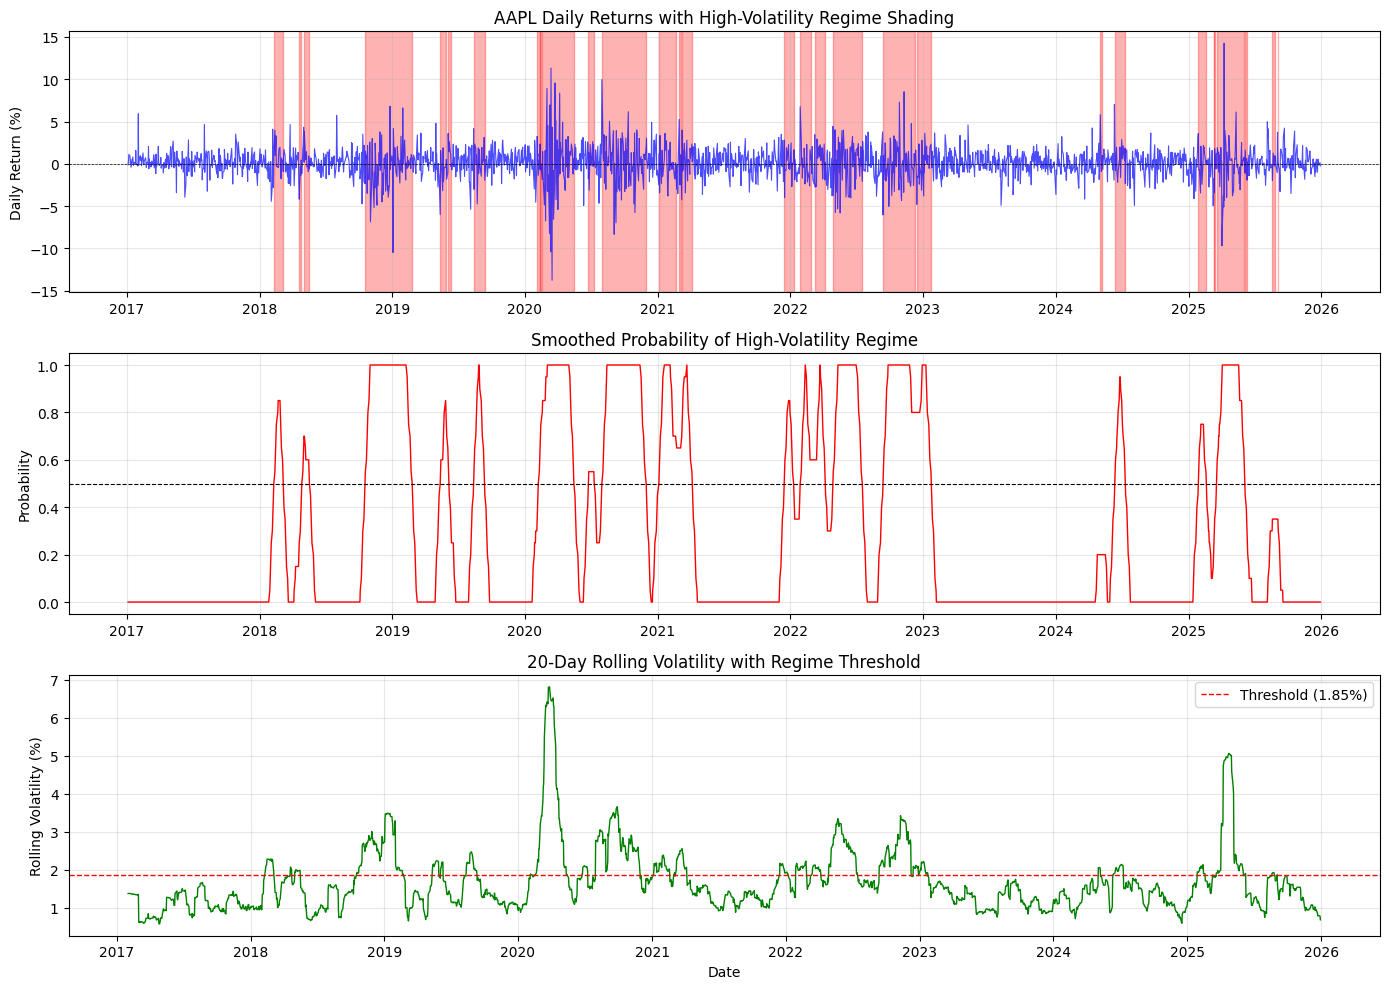


â Saved: regime_plot.png


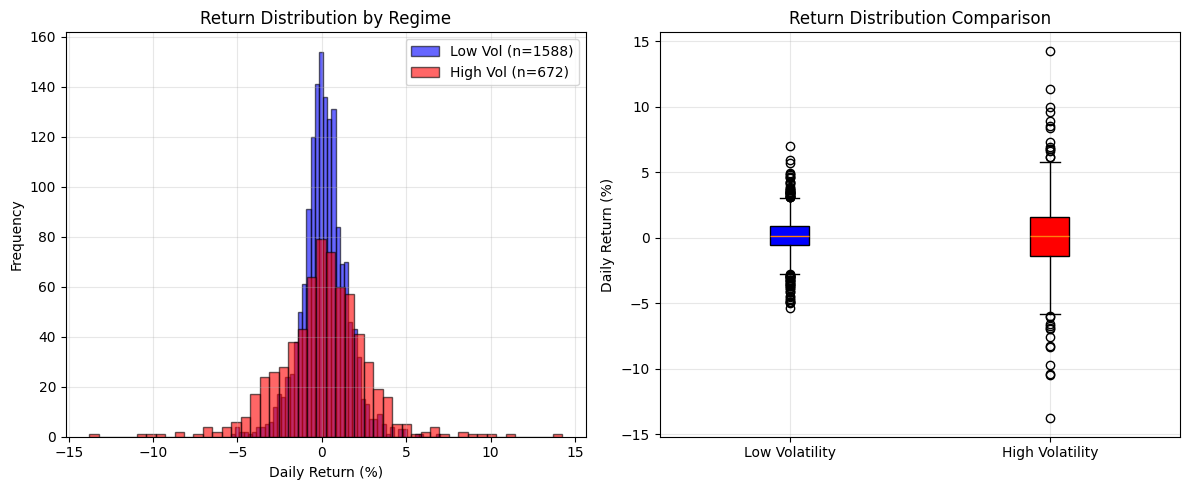

â Saved: diagnostic_plot.png


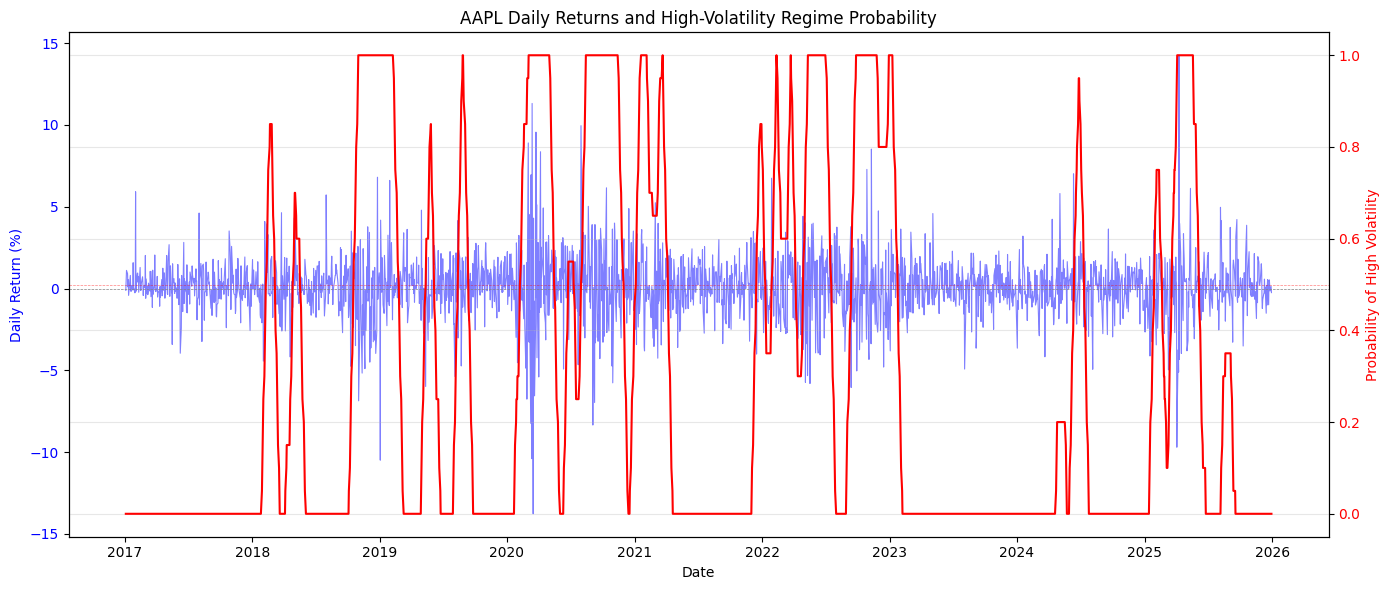

â Saved: combined_plot.png

ALL FILES SAVED SUCCESSFULLY!

Files in your folder:
  - REGIMECHANGE.py (this script)


In [13]:
import math
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from dataclasses import dataclass
import warnings
warnings.filterwarnings('ignore')

# =========================
# DATA STRUCTURE
# =========================
@dataclass
class StockData:
    date: str
    close: float
    log_return: float = 0.0


# =========================
# DATA LOADER
# =========================
class DataDownloader:

    @staticmethod
    def get_data():
        return yf.download("AAPL", start="2017-01-01", end="2025-12-31")


# =========================
# REGIME DETECTION USING ROLLING VOLATILITY
# =========================
def detect_regimes_simple(returns, window=20, vol_percentile=70):
    rolling_vol = returns.rolling(window=window).std()
    threshold = rolling_vol.quantile(vol_percentile / 100)
    regimes = (rolling_vol > threshold).astype(int)
    prob_high_vol = regimes.rolling(window=window, center=True).mean().fillna(0)
    return regimes, prob_high_vol, rolling_vol, threshold


# =========================
# MAIN PROGRAM
# =========================
def main():

    df = DataDownloader.get_data()

    if df is None or df.empty:
        print("No data loaded.")
        return

    print("Loaded:", len(df))

    # =========================
    # SAFE EXTRACTION
    # =========================
    dates = df.index.to_numpy()
    closes = df["Close"].to_numpy()

    data_list = []

    for i in range(len(df)):
        data_list.append(
            StockData(
                date=str(dates[i]),
                close=float(closes[i].item())
            )
        )

    # =========================
    # LOG RETURNS
    # =========================
    print("\n=== LOG RETURNS (First 5 rows) ===")

    data_list[0].log_return = 0.0

    for i in range(1, len(data_list)):
        prev = data_list[i - 1].close
        curr = data_list[i].close
        data_list[i].log_return = math.log(curr / prev)

        if i <= 5:
            print(
                data_list[i].date[:10],
                "| Close:", round(curr, 2),
                "| LogReturn:", round(data_list[i].log_return, 6)
            )

    # =========================
    # PREPARE RETURNS FOR MODEL
    # =========================
    returns_array = np.array([d.log_return for d in data_list[1:]])
    returns_series = pd.Series(returns_array * 100, index=df.index[1:])

    print(f"\nReturns ready: {len(returns_array)} observations")
    print(f"Date range: {returns_series.index[0].date()} to {returns_series.index[-1].date()}")

    # =========================
    # REGIME DETECTION
    # =========================
    print("\n=== DETECTING REGIMES ===")

    window_size = 20
    regimes, prob_high_vol, rolling_vol, threshold = detect_regimes_simple(returns_series, window=window_size, vol_percentile=70)

    # Calculate regime statistics
    n_high_vol = regimes.sum()
    n_low_vol = len(regimes) - n_high_vol

    # Calculate transition probabilities
    transitions = regimes.diff()
    p00 = ( (regimes == 0) & (transitions == 0) ).sum() / max((regimes == 0).sum(), 1)
    p11 = ( (regimes == 1) & (transitions == 0) ).sum() / max((regimes == 1).sum(), 1)

    # Calculate regime means and variances
    low_vol_returns = returns_series[regimes == 0]
    high_vol_returns = returns_series[regimes == 1]

    low_vol_mean = low_vol_returns.mean() / 100
    high_vol_mean = high_vol_returns.mean() / 100
    low_vol_var = low_vol_returns.var() / 10000
    high_vol_var = high_vol_returns.var() / 10000

    print(f"\n===== REGIME DETECTION RESULTS =====")
    print(f"Regime threshold (70th percentile of rolling vol): {threshold:.4f}%")
    print(f"\nRegime Statistics:")
    print(f"  Low volatility days: {n_low_vol} ({n_low_vol/len(regimes)*100:.1f}%)")
    print(f"  High volatility days: {n_high_vol} ({n_high_vol/len(regimes)*100:.1f}%)")

    print(f"\nCalibrated Parameters:")
    print(f"  Low Volatility Regime:")
    print(f"    - Mean return: {low_vol_mean:.6f}%")
    print(f"    - Variance: {low_vol_var:.6f}")
    print(f"  High Volatility Regime:")
    print(f"    - Mean return: {high_vol_mean:.6f}%")
    print(f"    - Variance: {high_vol_var:.6f}")

    print(f"\nTransition Probabilities:")
    print(f"  P(stay in low volatility) = {p00:.4f}")
    print(f"  P(stay in high volatility) = {p11:.4f}")
    print(f"  Expected duration low volatility: {1/(1-p00):.1f} days")
    print(f"  Expected duration high volatility: {1/(1-p11):.1f} days")

    # =========================
    # PLOT 1: RETURNS WITH REGIME SHADING
    # =========================
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # Top plot: Returns with high-volatility shading
    axes[0].plot(returns_series.index, returns_series, color='blue', alpha=0.7, linewidth=0.8)
    axes[0].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    axes[0].set_ylabel("Daily Return (%)")
    axes[0].set_title("AAPL Daily Returns with High-Volatility Regime Shading")
    axes[0].grid(True, alpha=0.3)

    # Shade high-volatility periods
    in_high_vol = False
    start_idx = None

    for i in range(len(regimes)):
        if regimes.iloc[i] == 1 and not in_high_vol:
            start_idx = i
            in_high_vol = True
        elif regimes.iloc[i] == 0 and in_high_vol:
            axes[0].axvspan(returns_series.index[start_idx], returns_series.index[i],
                           alpha=0.3, color='red')
            in_high_vol = False

    if in_high_vol:
        axes[0].axvspan(returns_series.index[start_idx], returns_series.index[-1],
                       alpha=0.3, color='red')

    # Middle plot: Probability of high-volatility regime
    axes[1].plot(prob_high_vol.index, prob_high_vol, color='red', linewidth=1)
    axes[1].axhline(y=0.5, color='black', linestyle='--', linewidth=0.8)
    axes[1].set_ylabel("Probability")
    axes[1].set_title("Smoothed Probability of High-Volatility Regime")
    axes[1].set_ylim(-0.05, 1.05)
    axes[1].grid(True, alpha=0.3)

    # Bottom plot: Rolling volatility
    axes[2].plot(rolling_vol.index, rolling_vol, color='green', linewidth=1)
    axes[2].axhline(y=threshold, color='red', linestyle='--', linewidth=1, label=f'Threshold ({threshold:.2f}%)')
    axes[2].set_ylabel("Rolling Volatility (%)")
    axes[2].set_xlabel("Date")
    axes[2].set_title(f"{window_size}-Day Rolling Volatility with Regime Threshold")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("regime_plot.png", dpi=150, bbox_inches='tight')
    plt.show()

    print("\nâ Saved: regime_plot.png")

    # =========================
    # PLOT 2: DIAGNOSTIC - RETURN DISTRIBUTIONS BY REGIME
    # =========================
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Histogram
    axes[0].hist(returns_series[regimes == 0], bins=50, alpha=0.6,
                label=f'Low Vol (n={n_low_vol})', color='blue', edgecolor='black')
    axes[0].hist(returns_series[regimes == 1], bins=50, alpha=0.6,
                label=f'High Vol (n={n_high_vol})', color='red', edgecolor='black')
    axes[0].set_xlabel("Daily Return (%)")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title("Return Distribution by Regime")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Box plot
    box_data = [returns_series[regimes == 0].dropna(), returns_series[regimes == 1].dropna()]
    bp = axes[1].boxplot(box_data, labels=['Low Volatility', 'High Volatility'], patch_artist=True)
    bp['boxes'][0].set_facecolor('blue')
    bp['boxes'][1].set_facecolor('red')
    axes[1].set_ylabel("Daily Return (%)")
    axes[1].set_title("Return Distribution Comparison")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("diagnostic_plot.png", dpi=150, bbox_inches='tight')
    plt.show()

    print("â Saved: diagnostic_plot.png")

    # =========================
    # PLOT 3: TIME SERIES WITH PROBABILITY OVERLAY
    # =========================
    fig, ax = plt.subplots(figsize=(14, 6))

    ax2 = ax.twinx()

    ax.plot(returns_series.index, returns_series, color='blue', alpha=0.5, linewidth=0.8)
    ax.set_ylabel("Daily Return (%)", color='blue')
    ax.set_xlabel("Date")
    ax.tick_params(axis='y', labelcolor='blue')
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)

    ax2.plot(prob_high_vol.index, prob_high_vol, color='red', linewidth=1.5)
    ax2.set_ylabel("Probability of High Volatility", color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(-0.05, 1.05)
    ax2.axhline(y=0.5, color='red', linestyle='--', linewidth=0.5, alpha=0.5)

    plt.title("AAPL Daily Returns and High-Volatility Regime Probability")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("combined_plot.png", dpi=150, bbox_inches='tight')
    plt.show()

    print("â Saved: combined_plot.png")

    # =========================
    # FINAL SUMMARY
    # =========================
    print("\n" + "="*60)
    print("ALL FILES SAVED SUCCESSFULLY!")
    print("="*60)
    print("\nFiles in your folder:")
    print("  - REGIMECHANGE.py (this script)")



# =========================
# RUN PROGRAM
# =========================
if __name__ == "__main__":
    main()
